## Exploration du dataset "Oily, Dry and Normal Skin Types" from Kaggle

In [2]:
from pathlib import Path

# Racine du projet (remonter de vision/notebooks/ vers skinmatch/)
PROJECT_ROOT = Path("__file__").resolve().parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "skin_images" / "oily-dry-normal"

SPLITS = ["train", "valid", "test"]
CLASSES = ["dry", "normal", "oily"]
CLASS_COLORS = {"dry": "#2E75B6", "normal": "#3B6D11", "oily": "#854F0B"}

print(f"Racine projet : {PROJECT_ROOT}")
print(f"Dossier data  : {DATA_DIR}")
print(f"Existe        : {DATA_DIR.exists()}")

Racine projet : /Users/ines.laguerre/Desktop/skinmatch
Dossier data  : /Users/ines.laguerre/Desktop/skinmatch/data/raw/skin_images/oily-dry-normal
Existe        : True


### Distribution

In [15]:
import pandas as pd 

# Comptage des images
records = []
for split in SPLITS:
    for cls in CLASSES:
        folder = DATA_DIR / split / cls
        if folder.exists():
            images = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png"))
            records.append({"split": split, "class": cls, "count": len(images), "path": folder})
        else:
            print(f"⚠️  Dossier manquant : {folder}")

df_counts = pd.DataFrame(records)

print("Proportions train / valid / test par classe:")

for cls in CLASSES:
    totals = {s: df_counts[(df_counts['split']==s) & (df_counts['class']==cls)]['count'].values[0] for s in SPLITS}
    total = sum(totals.values())
    print(f"  {cls.upper():8s} — total: {total:4d} | ", end="")
    for s in SPLITS:
        pct = totals[s] / total * 100
        print(f"{s}: {totals[s]:4d} ({pct:.0f}%)  ", end="")
    print()

print()
total_all = df_counts['count'].sum()
for s in SPLITS:
    n = df_counts[df_counts['split']==s]['count'].sum()
    print(f"  {s.upper():8s} — {n:4d} images ({n/total_all*100:.0f}% du total)")

Proportions train / valid / test par classe:
  DRY      — total:  758 | train:  652 (86%)  valid:   71 (9%)  test:   35 (5%)  
  NORMAL   — total: 1274 | train: 1104 (87%)  valid:  111 (9%)  test:   59 (5%)  
  OILY     — total: 1120 | train: 1000 (89%)  valid:   80 (7%)  test:   40 (4%)  

  TRAIN    — 2756 images (87% du total)
  VALID    —  262 images (8% du total)
  TEST     —  134 images (4% du total)


#### Conclusions

**Volumétrie globale** : 3 152 images au total, dont 2 756 en train. C'est un dataset de taille modeste mais suffisant pour du fine-tuning d'un modèle pré-entraîné (source?).

**Qualité du split** : le split fourni par les auteurs est conservé tel quel pour deux raisons importantes :
- Les proportions train / valid / test (~87% / 8% / 5%) sont **cohérentes et stables entre les 3 classes**, ce qui garantit que chaque split est représentatif de la distribution globale.
- Les auteurs ont appliqué de la **data augmentation** sur ce dataset avant de publier. Refaire un split nous-mêmes créerait du **leakage** : des images augmentées issues du même original se retrouveraient à la fois en train et en valid, ce qui gonflerait artificiellement les métriques de validation.

**Déséquilibre des classes** : la distribution n'est pas parfaitement équilibrée :
- `normal` est sur-représentée
- `dry` est sous-représentée

Ce déséquilibre modéré est gérable. On compensera avec un **`WeightedRandomSampler`** dans le DataLoader ou en passant des **`class_weight`** à la CrossEntropyLoss, afin d'éviter que le modèle ne soit biaisé vers la prédiction `normal`.

**Limite du test set** : avec seulement 134 images de test (dont 35 pour `dry`), les métriques finales auront une variance élevée. C'est une limite du dataset. 

### Dimensions des images

In [ ]:
from PIL import Image

# Échantillonnage des dimensions (sur le train set uniquement)
dim_records = []

for cls in CLASSES:
    folder = DATA_DIR / "train" / cls
    images = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png"))
    # Échantillon de 50 images max par classe pour aller vite
    sample = images[:50]
    for img_path in sample:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                dim_records.append({
                    "class": cls,
                    "width": w,
                    "height": h,
                    "ratio": round(w/h, 2),
                    "mode": img.mode,
                    "filename": img_path.name
                })
        except Exception as e:
            print(f"Image corrompue : {img_path.name} — {e}")

df_dims = pd.DataFrame(dim_records)

print("Statistiques des dimensions (train set, échantillon 50 images/classe):")
print(df_dims.groupby("class")[["width", "height", "ratio"]].describe().round(1).to_string())
print(f"Modes couleur uniques : {df_dims['mode'].unique()}")

Statistiques des dimensions (train set, échantillon 50 images/classe):
       width                                                height                                                ratio                                   
       count   mean  std    min    25%    50%    75%    max  count   mean  std    min    25%    50%    75%    max count mean  std  min  25%  50%  75%  max
class                                                                                                                                                     
dry     50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  50.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0
normal  50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  50.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0
oily    50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  50.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0

#### Conclusions

Les images sont **toutes identiques** : 640×640 pixels, ratio 1:1, mode RGB. 
C'est un dataset homogène sur ce plan, les auteurs ont vraisemblablement preprocessé les images avant de publier le dataset.

**Ce que ça implique pour `train.py`** :
- Un simple `Resize(224)` suffira puisque toutes les images sont déjà carrées
- Pas de `.convert('RGB')` nécessaire, toutes les images sont déjà en RGB
- La pipeline de prétraitement sera donc :
  1. `Resize(224)` (downscale direct de 640 à 224px)
  2. `Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])` (normalisation ImageNet)

Les auteurs semblent avoir déjà nettoyé le dataset en profondeur.

### Analyse d'échantillons d'image

On affiche une grille de **5 images par classe** (dry, normal, oily) issues du **train set uniquement**, avec un **tirage aléatoire** (`random.seed(42)` pour la reproductibilité).

On regarde **les 3 classes côte à côte** pour pouvoir comparer directement leurs caractéristiques visuelles et identifier ce qui les distingue ou les rapproche.

**Ce qu'on cherche à évaluer :**
- Les images dry ressemblent-elles bien à de la peau sèche (mate, terne, parfois squameuse) ?
- Les images oily ont-elles bien un aspect brillant/luisant caractéristique ?
- Les images normal sont-elles vraiment "entre les deux" — et donc potentiellement ambiguës ?
- Y a-t-il des images mal cadrées (zoom sur une zone de peau sans visage), floues, ou visiblement mal labellisées ?

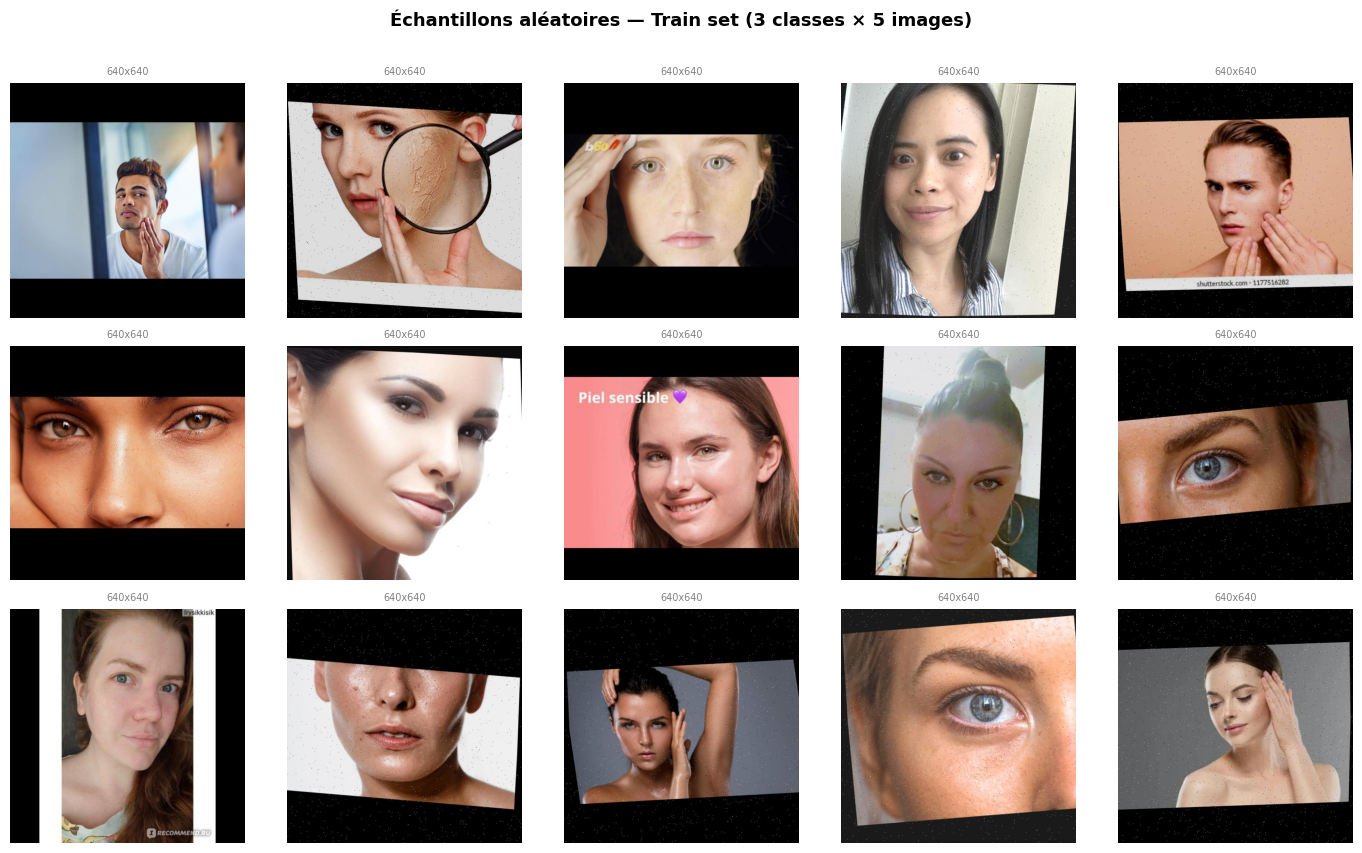

Sauvegarde : vision/notebooks/exemples_train.png


In [ ]:
import matplotlib.pyplot as plt
import random

# Grille d'exemples : 3 classes × 5 images par split
N_EXAMPLES = 5
random.seed(42)

fig, axes = plt.subplots(len(CLASSES), N_EXAMPLES, figsize=(N_EXAMPLES * 2.8, len(CLASSES) * 2.8))
fig.suptitle("Échantillons aléatoires — Train set (3 classes × 5 images)",
             fontsize=13, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASSES):
    folder = DATA_DIR / "train" / cls
    all_images = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png"))
    sample = random.sample(all_images, min(N_EXAMPLES, len(all_images)))

    for col, img_path in enumerate(sample):
        ax = axes[row, col]
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{img.size[0]}x{img.size[1]}", fontsize=7, color='gray')
        if col == 0:
            ax.set_ylabel(cls.upper(), fontsize=12, fontweight='bold',
                          color=CLASS_COLORS[cls], rotation=90, labelpad=12)
            ax.yaxis.set_label_position('left')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "vision" / "notebooks" / "exemples_train.png", dpi=120, bbox_inches='tight')
plt.show()
print("Sauvegarde : vision/notebooks/exemples_train.png")

#### Observations et conclusions

**Caractéristiques visuelles attendues par classe :**
- **Dry** : manque de gras, des rougeurs, desquamations, peau fine et rugeuse, pores non visibles, rares points noirs, tâches rouges, fines rides autour de la bouche et/ou des yeux
- **Normal** : peau équilibrée, ni brillante ni terne, pas d'imperfections visibles
- **Oily** : reflets brillants visibles, notamment dans la zone T (front, nez, menton), aspect luisant, pores parfois dilatés

**Observation par classe :**
- **Dry** : on dirait plutôt des peaux normales, sauf l'évidence avec la loupe de la deuxième photo
- **Normal** : peau parfois légèrement brillante, parfois pas un visage entier, présence de texte sur la troisième photo
- **Oily** : on voit bien des reflets brillants, ainsi que la présence de pores dilatées, sauf sur la première photo où la peau semble plutôt normale

**Conclusions pour le modèle :**
- Des confusions entre normal et les autres classes fréquentes : surveiller particulièrement le **F1 par classe** plutôt que l'accuracy globale
- Si certaines images sont des zooms serrés sur une zone de peau plutôt que des photos de visage entier, ce qui risque de poser problème à l'inférence puisque l'utilisateur uploadera un selfie : faire une prétraitement **MediaPipe** pour filtrer sur les visages
- Des images potentiellement mal labellisées qui contribueront à une partie des erreurs de classification.

### Distribution RGB

**Pourquoi regarder la distribution RGB ?**

Les valeurs RGB moyennes d'une image donnent une indication sur sa couleur et sa luminosité globales. En comparant ces distributions entre les 3 classes, on cherche à répondre à une question clé avant d'entraîner le modèle : **les classes ont-elles des signatures visuelles globalement distinctes, ou se ressemblent-elles trop ?**

- Si les distributions se **séparent clairement** : le modèle aura des features couleur exploitables dès les premières couches, la classification sera plus facile.
- Si les distributions se **superposent fortement** : le modèle devra s'appuyer sur des features plus fines comme la texture et la brillance locale, ce qui est plus difficile et demande plus d'epochs d'entraînement.

On s'attend à ce que `oily` ait des valeurs R plus élevées (reflets chauds du sébum) et que `dry` soit plus lumineux mais plus terne (mat). `normal` devrait se situer entre les deux.

In [22]:
import numpy as np

# Distribution des moyennes RGB par classe (sur échantillon train)
# Utile pour vérifier que les classes ont des signatures visuelles distinctes

rgb_records = []
N_SAMPLE = 30
random.seed(42)

for cls in CLASSES:
    folder = DATA_DIR / "train" / cls
    images = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg"))
    sample = random.sample(images, min(N_SAMPLE, len(images)))
    for img_path in sample:
        try:
            img = Image.open(img_path).convert("RGB").resize((128, 128))
            arr = np.array(img)
            rgb_records.append({
                "class": cls,
                "mean_R": arr[:,:,0].mean(),
                "mean_G": arr[:,:,1].mean(),
                "mean_B": arr[:,:,2].mean(),
                "brightness": arr.mean()
            })
        except:
            pass

df_rgb = pd.DataFrame(rgb_records)

print("Moyennes RGB par classe (train set, échantillon 30 images) :")
print(df_rgb.groupby("class")[["mean_R", "mean_G", "mean_B", "brightness"]].mean().round(1).to_string())

Moyennes RGB par classe (train set, échantillon 30 images) :
        mean_R  mean_G  mean_B  brightness
class                                     
dry      115.2    97.1    89.0       100.4
normal   126.5   110.5   102.7       113.2
oily     111.8    98.5    90.9       100.4


#### Conclusions

**Ce qu'on observe :**
- `normal` est la classe la plus lumineuse (brightness 113.2) et la plus "chaude" sur les 3 canaux. C'est contre-intuitif — on aurait attendu `oily` plus lumineux à cause des reflets du sébum. Cela peut indiquer que les photos `normal` ont été prises dans des conditions d'éclairage plus favorables, ou que le dataset introduit un biais de conditions de capture par classe.
- `dry` et `oily` ont des luminosités **identiques** (100.4) et des valeurs RGB très proches (écart max de ~3 points). Cela signifie que ces deux classes sont **quasi indiscernables par la couleur globale**.
- Les 3 distributions se superposent très fortement.

**Ce que ça signifie pour le modèle :**
C'est le signal le plus important de toute cette EDA. La couleur globale n'est **pas un critère discriminant** entre les classes — en particulier entre `dry` et `oily` qui ont des moyennes RGB quasi identiques. Le modèle ne pourra pas s'appuyer sur des features de couleur grossières pour classifier : il devra impérativement capturer des **features de texture fine** (brillance locale, pores, desquamation) que seules les couches profondes d'un modèle de neurones peuvent extraire.

Cela confirme deux choses :
1. Le fine-tuning complet (ou partiel en dégelant progressivement les couches) sera probablement nécessaire.
2. Les métriques d'entraînement pourraient être trompeuses si le modèle apprend à prédire `normal` systématiquement (classe majoritaire et la plus lumineuse) donc le F1 par classe dans MLflow sera l'indicateur à surveiller en priorité.

## Décisions

| Point | Observation | Décision |
|-------|-------------|----------|
| Volumétrie | 3 152 images, 2 756 en train | Suffisant pour fine-tuning |
| Split | ~87/8/5%, stable entre classes, dataset pré-augmenté | Conserver le split des auteurs |
| Déséquilibre | normal (40%) > oily (36%) > dry (24%) | `WeightedRandomSampler` ou `class_weight` dans la loss |
| Dimensions | Homogènes | `Resize(224)` + Normalisation standard |
| Mode couleur | Normalement tout est RGB | `.convert('RGB')` au chargement par sécurité |
| Cadrage | Potentiellement mixte (visage entier vs zoom) | Faire un prétraitement MediaPipe |
| Signatures RGB | La couleur n'est pas un critère discriminant | Capturer des features de texture fine, renforce le besoin de fine-tuning |
| Confusion attendue | entre normal et dry ou oily | Surveiller F1 par classe, pas seulement l'accuracy |